In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("synthetic_credit_card_fraud_dataset.csv")

In [3]:
data.head()

,user_id,card_number,expiry_date,cvv,same_billing_shipping,ip_risk_score,label,browser_Chrome,browser_Edge,browser_Firefox,browser_Safari,device_type_Desktop,device_type_Mobile,device_type_Tablet,time_of_day_Afternoon,time_of_day_Evening,time_of_day_Morning,time_of_day_Night
0,U0001,4043321819600132,04/29,908,0,0.83,1,0,0,0,1,1,0,0,1,0,0,0
1,U0002,4379402654234,01/31,161,1,0.18,0,1,0,0,0,0,0,1,0,1,0,0
2,U0003,379407816184956,02/35,103,0,0.09,0,1,0,0,0,0,0,1,0,0,1,0
3,U0004,4316475255341928325,03/33,483,0,0.87,1,0,1,0,0,0,0,1,1,0,0,0
4,U0005,4030564139537675,09/27,238,1,0.72,1,1,0,0,0,0,1,0,0,0,0,1


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                2000 non-null   str    
 1   card_number            2000 non-null   int64  
 2   expiry_date            2000 non-null   str    
 3   cvv                    2000 non-null   int64  
 4   same_billing_shipping  2000 non-null   int64  
 5   ip_risk_score          2000 non-null   float64
 6   label                  2000 non-null   int64  
 7   browser_Chrome         2000 non-null   int64  
 8   browser_Edge           2000 non-null   int64  
 9   browser_Firefox        2000 non-null   int64  
 10  browser_Safari         2000 non-null   int64  
 11  device_type_Desktop    2000 non-null   int64  
 12  device_type_Mobile     2000 non-null   int64  
 13  device_type_Tablet     2000 non-null   int64  
 14  time_of_day_Afternoon  2000 non-null   int64  
 15  time_of_day_Eve

In [5]:
data.describe()

,card_number,cvv,same_billing_shipping,ip_risk_score,label,browser_Chrome,browser_Edge,browser_Firefox,browser_Safari,device_type_Desktop,device_type_Mobile,device_type_Tablet,time_of_day_Afternoon,time_of_day_Evening,time_of_day_Morning,time_of_day_Night
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.054570e+17,833.293500,0.511500,0.499175,0.500000,0.25200,0.248500,0.242000,0.257500,0.329500,0.338000,0.332500,0.250000,0.258000,0.233000,0.259000
std,1.288763e+18,1423.779458,0.499993,0.358620,0.500125,0.43427,0.432251,0.428401,0.437366,0.470149,0.473147,0.471227,0.433121,0.437643,0.422848,0.438195
min,6.041475e+10,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.800367e+14,263.750000,0.000000,0.150000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.525345e+15,547.000000,1.000000,0.500000,0.500000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.620931e+15,799.250000,1.000000,0.850000,1.000000,1.00000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.250000,1.000000,0.000000,1.000000
max,4.996833e+18,9980.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
data.shape

(2000, 18)

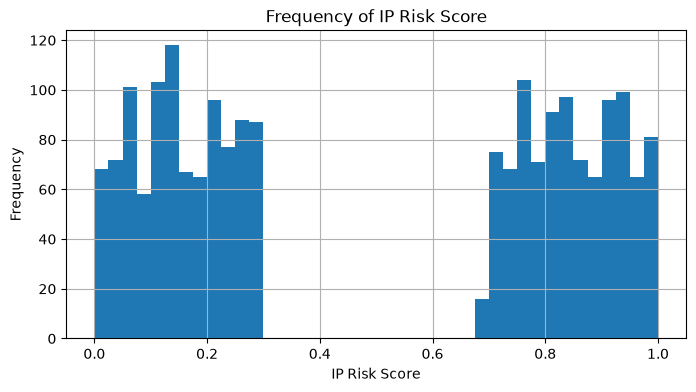

In [7]:
data['ip_risk_score'].hist(bins=40, figsize=(8, 4))
plt.xlabel("IP Risk Score")
plt.ylabel("Frequency")
plt.title("Frequency of IP Risk Score")
plt.show()

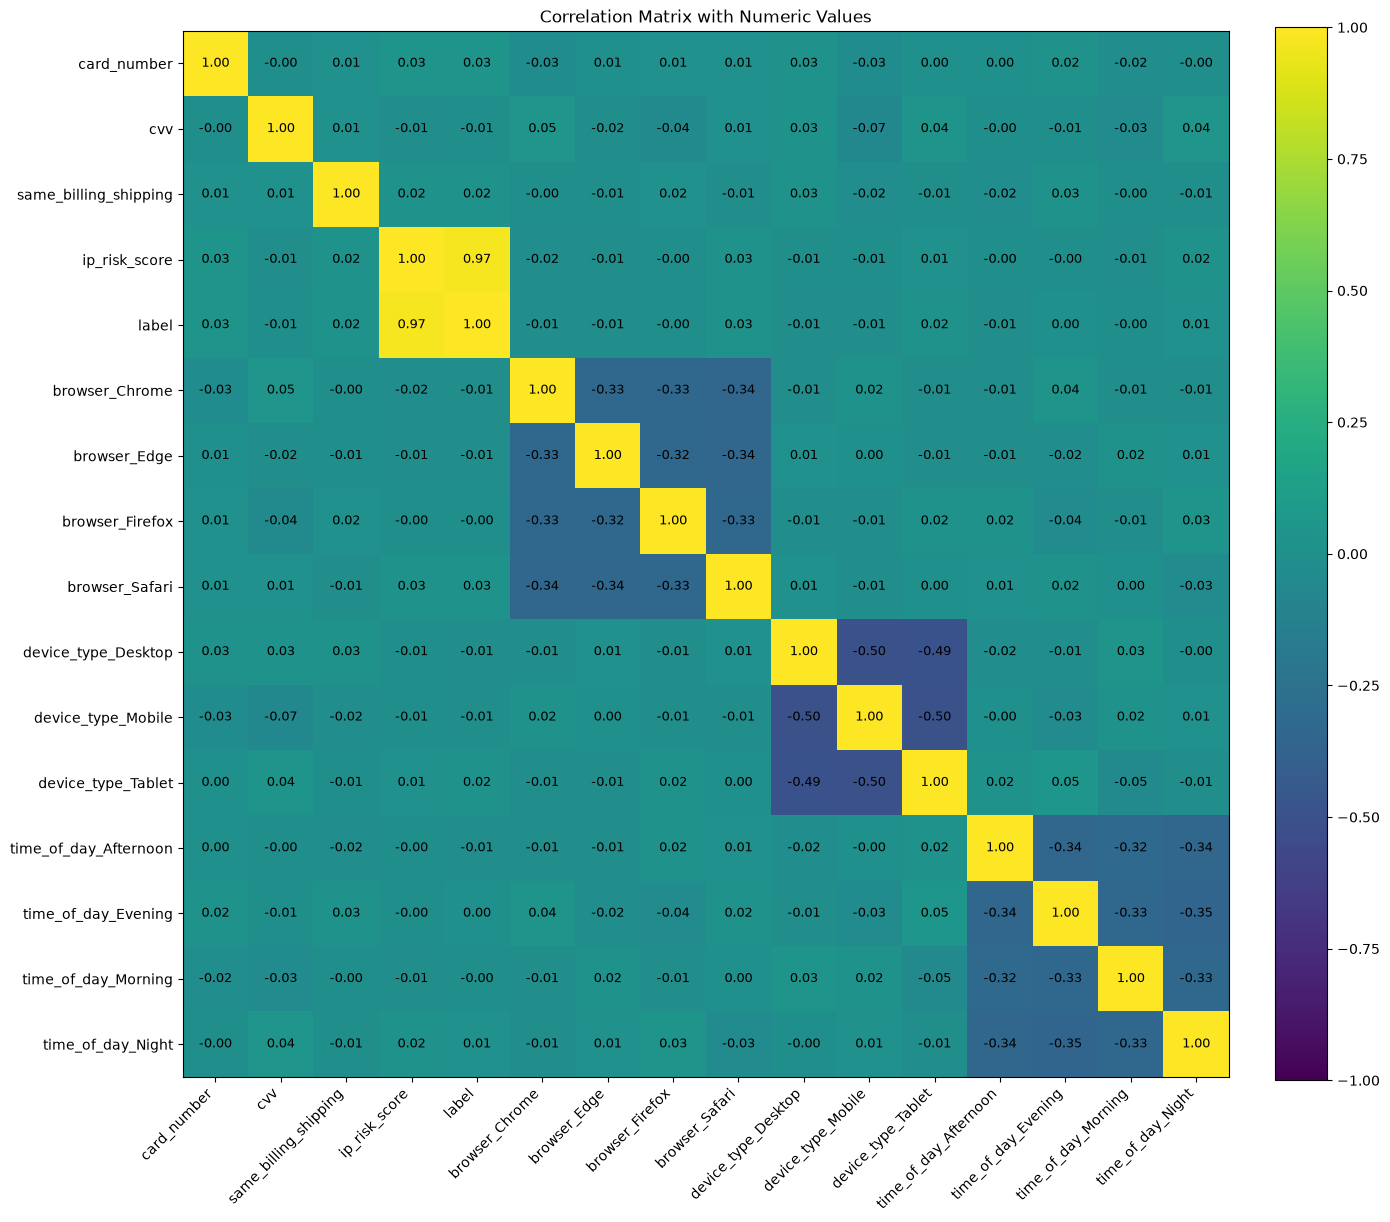

In [8]:
numeric_train = data.select_dtypes(include=[np.number])
corr_matrix = numeric_train.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(14, 14))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.title("Correlation Matrix with Numeric Values")
plt.tight_layout()
plt.show()

In [9]:
def preprocess_pipeline_withip(data):
    X = data.drop(columns=['label','user_id', 'card_number', 'cvv','browser_Firefox', 'device_type_Desktop','time_of_day_Morning'])
    y = data["label"]

    
    dates = pd.to_datetime(data['expiry_date'], format='%m/%y')
    month = dates.dt.month
    year = dates.dt.year
    X["months_until_expiry"] = year + (month /12)
    X = X.drop(columns=['expiry_date'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train[['ip_risk_score', 'months_until_expiry']]= scaler.fit_transform(X_train[['ip_risk_score', 'months_until_expiry']])
    X_test[['ip_risk_score', 'months_until_expiry']]= scaler.transform(X_test[['ip_risk_score', 'months_until_expiry']])

    return X_train, X_test, y_train, y_test
        

In [10]:
def preprocess_pipeline_withoutip(data):
    X_noip = data.drop(columns=['label','user_id', 'card_number', 'cvv', 'ip_risk_score', 'browser_Firefox', 'device_type_Desktop','time_of_day_Morning'])
    y_noip = data["label"]

    
    dates = pd.to_datetime(data['expiry_date'], format='%m/%y')
    month = dates.dt.month
    year = dates.dt.year
    X_noip["months_until_expiry"] = year + (month /12)
    X_no_ip = X_noip.drop(columns=['expiry_date'])

    X_train_no_ip, X_test_no_ip, y_train_no_ip, y_test_no_ip = train_test_split(X_no_ip, y_noip, test_size=0.2, random_state=42, stratify=y_noip)

    scaler = StandardScaler()
    X_train_no_ip[['months_until_expiry']]= scaler.fit_transform(X_train_no_ip[['months_until_expiry']])
    X_test_no_ip[['months_until_expiry']]= scaler.transform(X_test_no_ip[['months_until_expiry']])

    return X_train_no_ip, X_test_no_ip, y_train_no_ip, y_test_no_ip

In [11]:
preprocess_pipeline_withip(data)

(      same_billing_shipping  ip_risk_score  browser_Chrome  browser_Edge  \
 946                       1       0.892294               0             1   
 976                       1       0.975962               0             0   
 1001                      0      -0.753163               0             1   
 1219                      1      -0.976275               1             0   
 1034                      1       0.780738               0             0   
 ...                     ...            ...             ...           ...   
 453                       1       0.892294               0             1   
 912                       1      -1.199388               0             1   
 468                       0       1.143296               0             1   
 579                       1       0.836516               0             0   
 1067                      0       1.059629               0             0   
 
       browser_Safari  device_type_Mobile  device_type_Tablet  \
 946     

In [12]:
preprocess_pipeline_withoutip(data)

(      same_billing_shipping  browser_Chrome  browser_Edge  browser_Safari  \
 946                       1               0             1               0   
 976                       1               0             0               1   
 1001                      0               0             1               0   
 1219                      1               1             0               0   
 1034                      1               0             0               1   
 ...                     ...             ...           ...             ...   
 453                       1               0             1               0   
 912                       1               0             1               0   
 468                       0               0             1               0   
 579                       1               0             0               0   
 1067                      0               0             0               0   
 
       device_type_Mobile  device_type_Tablet  time_of_day_Aft

**Algorithm #1: Logistic Regression** 

In [13]:
#With IP Risk Score
X_train, X_test, y_train, y_test = preprocess_pipeline_withip(data)

#Create Validation Set
X_train_lr, X_val_lr, y_train_lr, y_val_lr = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

#Add Bias Columns
X_train_bias = np.c_[np.ones((X_train_lr.shape[0], 1)), X_train_lr]
X_val_bias = np.c_[np.ones((X_val_lr.shape[0], 1)), X_val_lr]
X_test_bias = np.c_[np.ones((X_test.shape[0], 1)), X_test]

In [14]:
# Without IP Risk Score
X_train_no_ip, X_test_no_ip, y_train_no_ip, y_test_no_ip = preprocess_pipeline_withoutip(data)

#Create Validation Set
X_train_no_ip_lr, X_val_no_ip_lr, y_train_no_ip_lr, y_val_no_ip_lr = train_test_split(
    X_train_no_ip,
    y_train_no_ip,
    test_size=0.25,
    random_state=42,
    stratify=y_train_no_ip
)

#Add Bias Columns
X_train_no_ip_bias = np.c_[np.ones((X_train_no_ip_lr.shape[0], 1)), X_train_no_ip_lr]
X_val_no_ip_bias = np.c_[np.ones((X_val_no_ip_lr.shape[0], 1)), X_val_no_ip_lr]
X_test_no_ip_bias = np.c_[np.ones((X_test_no_ip.shape[0], 1)), X_test_no_ip]

In [15]:
#Logistic Function
def logistic_regression(t):
    return 1 / (1 + np.exp(-t))

In [16]:
#Log Loss Cost Function
def log_loss(X, y, theta, epsilon=1e-7):
    p_hat = logistic_regression(X @ theta)
    return -np.mean(y * np.log(p_hat + epsilon) + (1 - y) * np.log(1 - p_hat + epsilon))

In [17]:
#Gradients Function
def gradients(X, y, theta):
    m = len(y)
    p_hat = logistic_regression(X @ theta)
    return (1/m) * X.T @ (p_hat - y)

In [18]:
#Batch Gradient Descent with IP Risk Score
eta = 0.1
n_epochs = 5000
record_every = 50
theta = np.random.default_rng(42).standard_normal(X_train_bias.shape[1])

epochs_recorded = []
train_losses = []
valid_losses = []

for epoch in range(n_epochs):
    grad = gradients(X_train_bias, y_train_lr, theta)
    theta = theta - eta * grad

    if epoch % record_every == 0:
        train_loss = log_loss(X_train_bias, y_train_lr, theta)
        val_loss = log_loss(X_val_bias, y_val_lr, theta)
        
        epochs_recorded.append(epoch)
        train_losses.append(train_loss)
        valid_losses.append(val_loss)

In [19]:
#Batch Gradient Descent without IP Risk Score
eta = 0.1
n_epochs = 5000
record_every = 50

theta_no_ip = np.random.default_rng(42).standard_normal(X_train_no_ip_bias.shape[1])

epochs_recorded_no_ip = []
train_losses_no_ip = []
valid_losses_no_ip = []

for epoch in range(n_epochs):
    grad = gradients(X_train_no_ip_bias, y_train_no_ip_lr, theta_no_ip)
    theta_no_ip = theta_no_ip - eta * grad

    if epoch % record_every == 0:
        train_loss = log_loss(X_train_no_ip_bias, y_train_no_ip_lr, theta_no_ip)
        val_loss = log_loss(X_val_no_ip_bias, y_val_no_ip_lr, theta_no_ip)

        epochs_recorded_no_ip.append(epoch)
        train_losses_no_ip.append(train_loss)
        valid_losses_no_ip.append(val_loss)

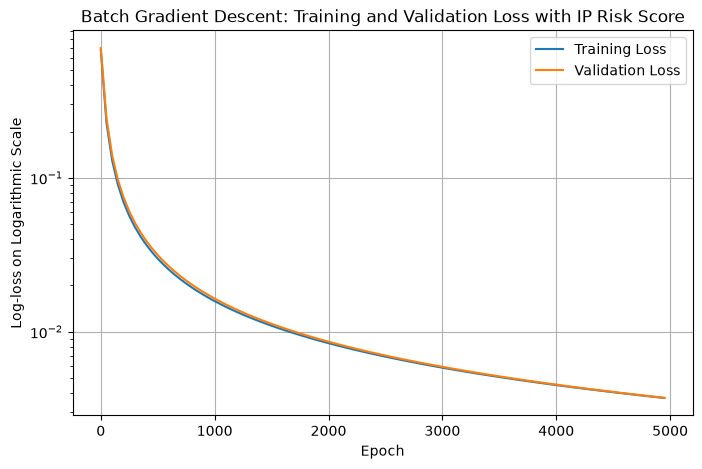

In [20]:
#Learning Curves with IP Risk Score
plt.figure(figsize=(8, 5))

plt.plot(epochs_recorded, train_losses, label="Training Loss")
plt.plot(epochs_recorded, valid_losses, label="Validation Loss")

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("Log-loss on Logarithmic Scale")
plt.title("Batch Gradient Descent: Training and Validation Loss with IP Risk Score")

plt.legend()
plt.grid(True)

plt.show()

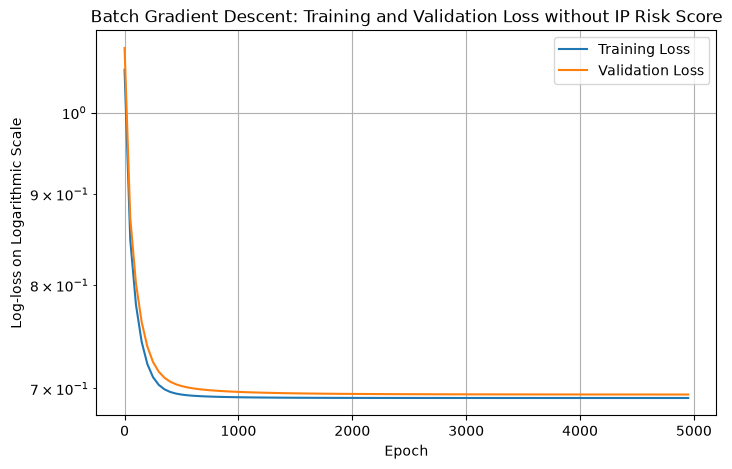

In [21]:
#Learning Curves without IP Risk Score
plt.figure(figsize=(8, 5))

plt.plot(epochs_recorded_no_ip, train_losses_no_ip, label="Training Loss")
plt.plot(epochs_recorded_no_ip, valid_losses_no_ip, label="Validation Loss")

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("Log-loss on Logarithmic Scale")
plt.title("Batch Gradient Descent: Training and Validation Loss without IP Risk Score")

plt.legend()
plt.grid(True)

plt.show()

In [22]:
#Early Stopping Logic with IP Risk Score
best_loss = np.inf
best_theta = None
best_epoch = 0
patience = 100

theta = np.random.default_rng(42).standard_normal(X_train_bias.shape[1])

epochs_recorded = []
train_losses = []
valid_losses = []

epochs_without_improvement = 0

for epoch in range(n_epochs):
    grad = gradients(X_train_bias, y_train_lr, theta)
    theta = theta - eta * grad
    
    val_loss = log_loss(X_val_bias, y_val_lr, theta)
    
    if val_loss < best_loss:
        best_loss = val_loss
        best_theta = theta.copy()
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    
    if epoch % record_every == 0:
        epochs_recorded.append(epoch)
        train_losses.append(log_loss(X_train_bias, y_train_lr, theta))
        valid_losses.append(val_loss)
    
    if epochs_without_improvement >= patience:
        break

theta = best_theta.copy()

print("With IP Risk Score:")
print("Best Epoch:", best_epoch)
print("Best Loss:", best_loss)

With IP Risk Score:
Best Epoch: 4999
Best Loss: 0.0036819109935476734


In [23]:
# Early Stopping Logic without IP Risk Score
best_loss_no_ip = np.inf
best_theta_no_ip = None
best_epoch_no_ip = 0
patience = 100

theta_no_ip = np.random.default_rng(42).standard_normal(X_train_no_ip_bias.shape[1])

epochs_recorded_no_ip = []
train_losses_no_ip = []
valid_losses_no_ip = []

epochs_without_improvement = 0

for epoch in range(n_epochs):
    grad = gradients(X_train_no_ip_bias, y_train_no_ip_lr, theta_no_ip)
    theta_no_ip = theta_no_ip - eta * grad
    
    val_loss = log_loss(X_val_no_ip_bias, y_val_no_ip_lr, theta_no_ip)
    
    if val_loss < best_loss_no_ip:
        best_loss_no_ip = val_loss
        best_theta_no_ip = theta_no_ip.copy()
        best_epoch_no_ip = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    
    if epoch % record_every == 0:
        epochs_recorded_no_ip.append(epoch)
        train_losses_no_ip.append(log_loss(X_train_no_ip_bias, y_train_no_ip_lr, theta_no_ip))
        valid_losses_no_ip.append(val_loss)
    
    if epochs_without_improvement >= patience:
        break

theta_no_ip = best_theta_no_ip.copy()

print("Without IP Risk Score:")
print("Best Epoch:", best_epoch_no_ip)
print("Best Loss:", best_loss_no_ip)

Without IP Risk Score:
Best Epoch: 4999
Best Loss: 0.694584786716307


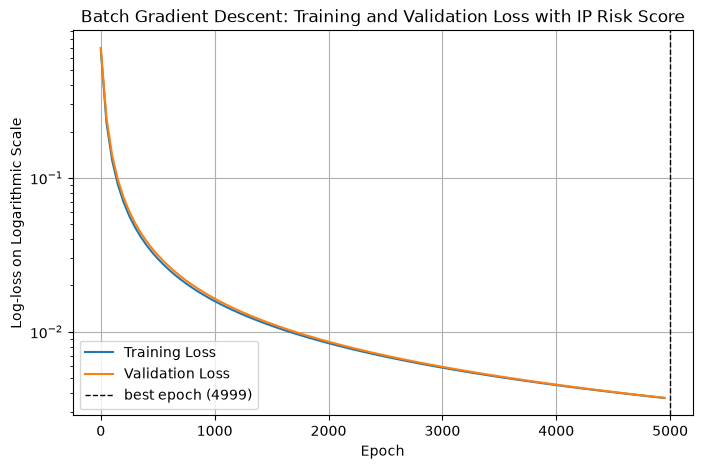

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(epochs_recorded, train_losses, label="Training Loss")
plt.plot(epochs_recorded, valid_losses, label="Validation Loss")

plt.axvline(
    best_epoch,
    color="k",
    ls="--",
    lw=1,
    label=f"best epoch ({best_epoch})"
)

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("Log-loss on Logarithmic Scale")
plt.title("Batch Gradient Descent: Training and Validation Loss with IP Risk Score")

plt.legend()
plt.grid(True)

plt.show()

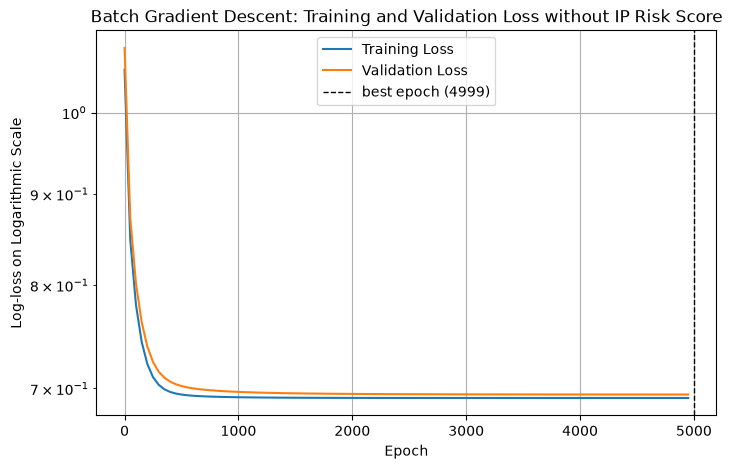

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(epochs_recorded_no_ip, train_losses_no_ip, label="Training Loss")
plt.plot(epochs_recorded_no_ip, valid_losses_no_ip, label="Validation Loss")

plt.axvline(
    best_epoch_no_ip,
    color="k",
    ls="--",
    lw=1,
    label=f"best epoch ({best_epoch_no_ip})"
)

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("Log-loss on Logarithmic Scale")
plt.title("Batch Gradient Descent: Training and Validation Loss without IP Risk Score")

plt.legend()
plt.grid(True)

plt.show()

**Algorithm #2: Random Forest** 

In [26]:
#Testing and training sets with and without IP risk score feature
X_train, X_test, y_train, y_test = preprocess_pipeline_withip(data)
X_train_no_ip, X_test_no_ip, y_train_no_ip, y_test_no_ip = preprocess_pipeline_withoutip(data)

In [27]:
#Creating random forest model
from sklearn.ensemble import RandomForestClassifier
randomForest = RandomForestClassifier(random_state = 42)

In [28]:
#Validation + hyperparameters: Stratified K-fold, Grid Search, and Randomized Search
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [29]:
#K-fold
skfold = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

skfold_scores = cross_val_score(
    randomForest,
    X_train,
    y_train,
    cv = skfold,
    scoring = "recall",
    n_jobs = -1
)
skfold_scores_no_ip = cross_val_score(
    randomForest,
    X_train_no_ip,
    y_train_no_ip,
    cv = skfold,
    scoring = "recall",
    n_jobs = -1
)
print("K-fold scores with IP:")
print(skfold_scores)
print("K-fold scores without IP:")
print(skfold_scores_no_ip)

K-fold scores with IP:
[1. 1. 1. 1. 1.]
K-fold scores without IP:
[0.525   0.56875 0.43125 0.55    0.48125]


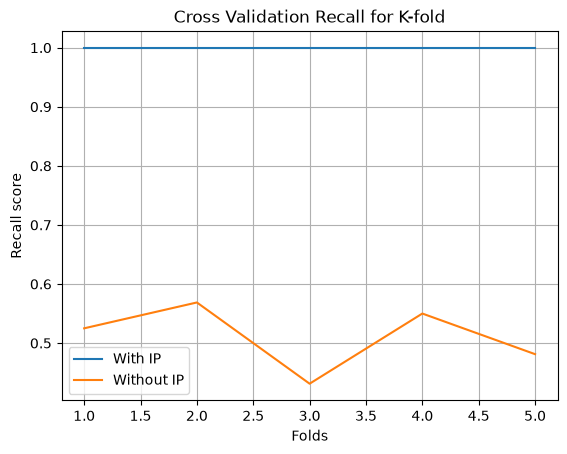

In [30]:
#K-fold visualization
plt.figure()
plt.plot(range(1, 6), skfold_scores, label = "With IP")
plt.plot(range(1, 6), skfold_scores_no_ip, label = "Without IP")
plt.grid(True)
plt.xlabel("Folds")
plt.ylabel("Recall score")
plt.title("Cross Validation Recall for K-fold")
plt.legend()
plt.show()

In [31]:
#Grid search
parameters_gs = {
    "n_estimators" : [100, 200, 500],
    "max_depth": [None, 5, 10, 20],
    "max_features": ['sqrt', 'log2'],
    "min_samples_split": [2, 5, 10], #prevents overfitting
    "min_samples_leaf": [1, 2, 4] #prevents overfitting
}

gridSearch = GridSearchCV(
    randomForest,
    param_grid = parameters_gs,
    cv = skfold,
    scoring = "recall",
    n_jobs = -1
)
gridSearch_no_ip = GridSearchCV(
    randomForest,
    param_grid = parameters_gs,
    cv = skfold,
    scoring = "recall",
    n_jobs = -1
)
gridSearch.fit(X_train, y_train)
gridSearch_no_ip.fit(X_train_no_ip, y_train_no_ip)

KeyboardInterrupt: 

In [ ]:
#Grid Search results:
print("-----Best parameters for grid search-----")
print("With IP:")
print(gridSearch.best_params_)
print("Without IP:")
print(gridSearch_no_ip.best_params_)
print("\n-----Best recall score-----")
print("With IP: ", gridSearch.best_score_)
print("Without IP: ", gridSearch_no_ip.best_score_)

In [ ]:
#Randomized Search
parameters_rs = {
    "n_estimators": range(100, 501, 50),
    "max_depth": range(5,20),
    "max_features": ['sqrt', 'log2'],
    "min_samples_split": range(2, 10), #prevents overfitting
    "min_samples_leaf": range(1, 10) #prevents overfitting
}

randomSearch = RandomizedSearchCV(
    randomForest,
    param_distributions = parameters_rs,
    n_iter = 50,
    cv = skfold,
    scoring = "recall",
    random_state = 42,
    n_jobs = -1
)
randomSearch_no_ip = RandomizedSearchCV(
    randomForest,
    param_distributions = parameters_rs,
    n_iter = 50,
    cv = skfold,
    scoring = "recall",
    random_state = 42,
    n_jobs = -1
)

randomSearch.fit(X_train, y_train)
randomSearch_no_ip.fit(X_train_no_ip, y_train_no_ip)

In [ ]:
#Randomized Search results
print("-----Best Random Parameters-----")
print("With IP:")
print(randomSearch.best_params_)
print("Without IP:")
print(randomSearch_no_ip.best_params_)

print("\n-----Best Random CV Score-----")
print("With IP:\t", randomSearch.best_score_)
print("Without IP:\t", randomSearch_no_ip.best_score_)

RSResults = pd.DataFrame(randomSearch.cv_results_)
topScores = RSResults.nlargest(10, "mean_test_score")
RSResults_no_ip = pd.DataFrame(randomSearch_no_ip.cv_results_)
topScores_no_ip = RSResults_no_ip.nlargest(10, "mean_test_score")

print("\n-----Top average scores-----")
print("With IP:")
print(topScores[["mean_test_score", "params"]])
print("\nWithout IP:")
print(topScores_no_ip[["mean_test_score", "params"]])

In [ ]:
#Testing both models
bestGrid = gridSearch.best_estimator_
bestRan = randomSearch.best_estimator_

bestGrid_no_ip = gridSearch_no_ip.best_estimator_
bestRan_no_ip = randomSearch_no_ip.best_estimator_

y_predict_grid = bestGrid.predict(X_test)
y_predict_ran = bestRan.predict(X_test)

y_predict_grid_no_ip = bestGrid_no_ip.predict(X_test_no_ip)
y_predict_ran_no_ip = bestRan_no_ip.predict(X_test_no_ip)

In [ ]:
#Grid search Recall scores and Confusion Matrices with IP risk feature
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay
print("Grid search results:")
print("Recall score:", recall_score(y_test, y_predict_grid))
print("Confusion matrix:")
ConfusionMatrixDisplay.from_estimator(bestGrid, X_test, y_test)

In [ ]:
#Random search Recall scores and Confusion Matrices with IP risk feature
print("Random search results:")
print("Recall score:", recall_score(y_test, y_predict_ran))
print("Confusion matrix:")
ConfusionMatrixDisplay.from_estimator(bestRan, X_test, y_test)

In [ ]:
#Grid search Recall scores and Confusion Matrices without IP risk feature
print("Grid search results:")
print("Recall score:", recall_score(y_test_no_ip, y_predict_grid_no_ip))
print("Confusion matrix:")
ConfusionMatrixDisplay.from_estimator(bestGrid_no_ip, X_test_no_ip, y_test_no_ip)

In [ ]:
#Random search Recall scores and Confusion Matrices without IP risk feature
print("Random search results:")
print("Recall score:", recall_score(y_test_no_ip, y_predict_ran_no_ip))
print("Confusion matrix:")
ConfusionMatrixDisplay.from_estimator(bestRan_no_ip, X_test_no_ip, y_test_no_ip)

In [ ]:
#Evaluate and Build Confusion Matrix

y_predict_lr = (logistic_regression(X_test_bias @ theta) >= 0.5).astype(int)
y_predict_lr_no_ip = (logistic_regression(X_test_no_ip_bias @ theta_no_ip) >= 0.5).astype(int)

In [ ]:
#Random logistic regression scores and Confusion Matrices with IP risk feature
print("Logistic Regression Results:")
print("Recall score:", recall_score(y_test, y_predict_lr))
print("Confusion matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_predict_lr)

Logistic Regression Results:


NameError: name 'y_predict_lr' is not defined

Logistic regression results:
Recall score: 0.47
Confusion matrix:


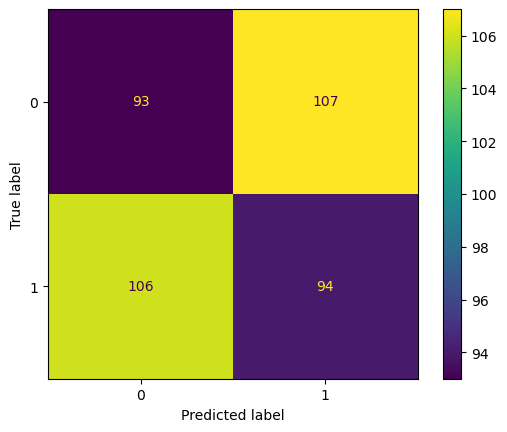

In [ ]:
#Random search Recall scores and Confusion Matrices without IP risk feature
print("Logistic regression results:")
print("Recall score:", recall_score(y_test_no_ip, y_predict_lr_no_ip))
print("Confusion matrix:")
ConfusionMatrixDisplay.from_predictions(y_test_no_ip, y_predict_lr_no_ip)

# AdaBoost Model

AdaBoost combines weak decision trees sequentially and gives more attention to samples that were misclassified by earlier trees.

In [74]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


## Create the Base AdaBoost Model

A decision stump is a small decision tree with one level. `n_estimators` sets the number of stumps, and `learning_rate` controls how strongly each stump contributes to the final model.

In [75]:
X_train, X_test, y_train, y_test = preprocess_pipeline_withip(data)

stump = DecisionTreeClassifier(max_depth=1, random_state=42)

ada_model = AdaBoostClassifier(
    estimator=stump,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)


## Cross-Validation

Five-fold cross-validation evaluates recall because this project prioritizes minimizing missed fraudulent transactions.

In [76]:
cv_scores = cross_val_score(
    ada_model,
    X_train,
    y_train,
    cv=5,
    scoring="recall"
)

print("Recall scores:", cv_scores)
print("Mean recall:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())


Recall scores: [1. 1. 1. 1. 1.]
Mean recall: 1.0
Standard deviation: 0.0


## Hyperparameter Tuning

Grid Search tests combinations of `n_estimators`, `learning_rate`, and the maximum depth of each decision-tree estimator to find the settings with the best cross-validation recall.

In [77]:
param_grid = {
    "n_estimators": [25, 50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0],
    "estimator__max_depth": [1, 2, 3]
}

grid_search = GridSearchCV(
    estimator=ada_model,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation recall:", grid_search.best_score_)


Best parameters: {'estimator__max_depth': 1, 'learning_rate': 0.01, 'n_estimators': 25}
Best cross-validation recall: 1.0


## Final Test Evaluation

The selected model is evaluated once on the held-out test set.

In [78]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



## Confusion Matrix

False negatives represent fraudulent transactions missed by the model.

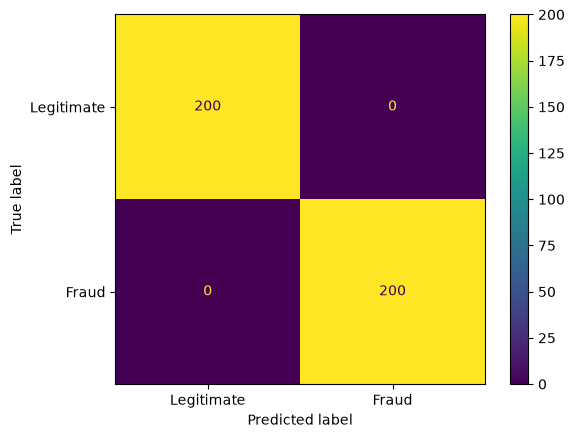

True negatives: 200
False positives: 0
False negatives: 0
True positives: 200


In [79]:
cm = confusion_matrix(y_test, y_pred)
display_labels = ["Legitimate", "Fraud"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot()
plt.show()

tn, fp, fn, tp = cm.ravel()
print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)


## Without IP Risk Score

In [80]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


## Create the Base AdaBoost Model

In [81]:
X_train, X_test, y_train, y_test = preprocess_pipeline_withoutip(data)

stump = DecisionTreeClassifier(max_depth=1, random_state=42)

ada_model = AdaBoostClassifier(
    estimator=stump,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)


## Cross-Validation

In [82]:
cv_scores = cross_val_score(
    ada_model,
    X_train,
    y_train,
    cv=5,
    scoring="recall"
)

print("Recall scores:", cv_scores)
print("Mean recall:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())


Recall scores: [0.33125 0.375   0.6     0.4875  0.5625 ]
Mean recall: 0.47125000000000006
Standard deviation: 0.10395311443145895


## Hyperparameter Tuning

In [83]:
param_grid = {
    "n_estimators": [25, 50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0],
    "estimator__max_depth": [1, 2, 3]
}

grid_search = GridSearchCV(
    estimator=ada_model,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation recall:", grid_search.best_score_)


Best parameters: {'estimator__max_depth': 2, 'learning_rate': 0.01, 'n_estimators': 50}
Best cross-validation recall: 0.5199999999999999


## Final Test Evaluation

In [84]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.535
              precision    recall  f1-score   support

           0       0.53      0.69      0.60       200
           1       0.55      0.38      0.45       200

    accuracy                           0.54       400
   macro avg       0.54      0.53      0.52       400
weighted avg       0.54      0.54      0.52       400



## Confusion Matrix

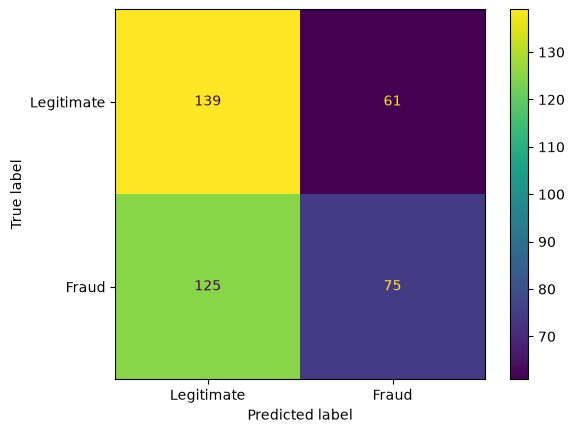

True negatives: 139
False positives: 61
False negatives: 125
True positives: 75


In [85]:
cm = confusion_matrix(y_test, y_pred)
display_labels = ["Legitimate", "Fraud"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot()
plt.show()

tn, fp, fn, tp = cm.ravel()
print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)
